# Analysis of Products

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "../data/processed/ah.csv"

df_ah = pd.read_csv(path)
df_ah = df_ah.drop_duplicates(subset="product_id")
df_ah = df_ah[df_ah["frac_kcal_protein"] <= 1.1] # 1.1 since 4kcal/protein(g) is an approximation
df_ah = df_ah[df_ah["frac_kcal_fat"] <= 1.1]
df_ah = df_ah[df_ah["frac_kcal_carbs"] <= 1.1]

print(f"Number of valid AH products: {len(df_ah)}")

path = "../data/processed/dirk.csv"

df_dirk = pd.read_csv(path)
df_dirk = df_dirk.drop_duplicates(subset="product_id")
df_dirk = df_dirk[df_dirk["frac_kcal_protein"] <= 1.1] # 1.1 since 4kcal/protein(g) is an approximation
df_dirk = df_dirk[df_dirk["frac_kcal_fat"] <= 1.1]
df_dirk = df_dirk[df_dirk["frac_kcal_carbs"] <= 1.1]

print(f"Number of valid Dirk products: {len(df_dirk)}")


Number of valid AH products: 9353
Number of valid Dirk products: 4843


## Price EDA

Dirk shows both a lower mean and median product price compared to AH, indicating that the products in the Dirk dataset are generally cheaper.

In [3]:
# AH
print("Mean price")
print(df_ah["price"].mean())
print("Median price")
print(df_ah["price"].median())

Mean price
3.731024270287608
Median price
2.79


In [4]:
# Dirk
print("Mean price")
print(df_dirk["price"].mean())
print("Median price")
print(df_dirk["price"].median())

Mean price
2.483578360520339
Median price
2.15


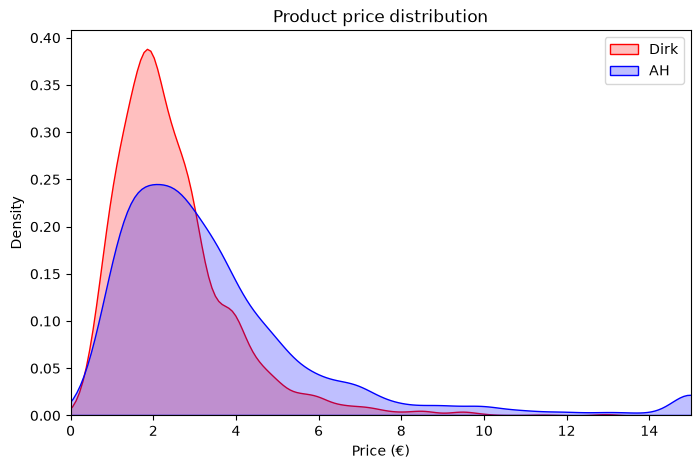

In [5]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    df_dirk["price"].clip(0, 15),
    label="Dirk",
    color="red",
    fill=True
)

sns.kdeplot(
    df_ah["price"].clip(0, 15),
    label="AH",
    color="blue",
    fill=True
)

plt.xlim(0, 15)
plt.xlabel("Price (€)")
plt.ylabel("Density")
plt.title("Product price distribution")
plt.legend()

plt.show()

### Price distribution

The price distributions are similar between supermarkets, with most products concentrated in the lower price range (1 to 4 euros). AH shows a slightly wider spread, including more high-priced products.

## Highest Protein Items

### Focussing one one store (AH)

In [6]:
# Highest protein/100g
highest_protein = df_ah.nlargest(5, "protein_g")
print(highest_protein[["name", "protein_g"]])

                                                    name  protein_g
58185           AH Clear whey protein poeder sinaasappel       86.0
58291  Optimum Nutrition Clear whey + collagen summer...       85.0
58305  Optimum Nutrition Clear whey + collagen apple ...       82.0
58543          ESN Isoclear whey protein strawberry lime       82.0
58557           ESN Isoclear whey protein peach iced tea       81.0


In [7]:
# Cheapest protein
highest_protein_euro = df_ah.nlargest(5, "protein_per_euro")
print(highest_protein_euro[["name", "protein_per_euro"]])

                                  name  protein_per_euro
61122           AH Zelfrijzend bakmeel        173.913043
40396                      AH Macaroni        136.842105
28325            AH Volkoren tarwemeel        134.831461
14271                    AH Tarwebloem        129.411765
40412  AH Biologisch Macaroni volkoren        118.644068


Dry wheat-based products appear to be the most affordable protein sources based on grams of protein per euro.

However, this comparison does not account for the proportion of calories derived from protein or differences in protein quality.

In [20]:
from supermarkt.plots import *

threshold_protein = 0
plot_affordability_vs_frac_protein_interactive(df_ah, threshold_protein=threshold_protein)

non_vegan = 1 - df_ah[df_ah["frac_kcal_protein"] > threshold_protein]["vegan"].mean()

print(f"Frac non-vegan: {non_vegan}")

Frac non-vegan: 0.5724759615384616


In [23]:
threshold_protein = 0.2

non_vegan = 1 - df_ah[df_ah["frac_kcal_protein"] > threshold_protein]["vegan"].mean()

print(f"Frac non-vegan: {non_vegan}")

Frac non-vegan: 0.6837573385518592


From the plot above, we observe that wheat-based products are the most affordable protein sources based on price per gram of protein. However, these products have a relatively low protein energy ratio, with only ~15% of their calories coming from protein (most come from carbohydrates).

When filtering for products where more than 20% of calories are derived from protein, the distribution becomes dominated by non-vegan products.

In [ ]:
plot_frac_fat_vs_frac_protein_interactive(df_ah.head(None))

In [ ]:
plot_macro_frac(df_ah.head(None))

The plots above shows differences in macronutrient composition between product categories:
- Most meat-based products derive a large proportion of their calories from protein and fat.
- Many vegetarian products have a higher contribution from fat and carbohydrates, with many products clustering towards lower protein fractions (e.g. snacks such as cookies and ice cream).
- Many vegan products derive the majority of their calories from carbohydrates, indicated by the concentration of points near the bottom of the plot.